# 🤖 OmniSupportEnv — GRPO Training (Google Colab)
This notebook trains a Qwen2.5-1.5B model using GRPO (Generative Reward Policy Optimization) to correctly handle customer support scenarios in the `OmniSupportEnv` environment.

**Requirements:**
- A GPU instance (T4 is fine, L4 or A100 is better)
- Hugging Face token (if pushing to hub, optional)

In [1]:
# We don't use -U to avoid breaking Colab's pre-installed PyTorch/CUDA
!pip install -q trl datasets pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.8 MB/s eta 0:00:00


### 1. Load the Environment Components
We define a local version of the environment rules and the reward functions.

In [2]:
import json
import random
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import Dataset
from trl import GRPOConfig, GRPOTrainer

# Simple mocked environment rules for the Colab training loop
# (This avoids needing to run the full FastAPI server during training)
VALID_ACTIONS = {"search_kb", "lookup_order", "check_account", "process_refund",
                 "flag_security", "ask_user", "send_response", "escalate", "resolve", "close_no_action"}

def reward_format(prompts, completions, **kwargs):
    """Is the output valid JSON with action_type and action_value?"""
    rewards = []
    for completion in completions:
        try:
            # TRL completions sometimes include the prompt or are just the generated text
            # We try to extract the JSON block
            text = completion[0]["content"] if isinstance(completion, list) else completion
            d = json.loads(text.strip())
            if "action_type" in d and "action_value" in d:
                rewards.append(1.0)
            else:
                rewards.append(0.3)
        except Exception:
            rewards.append(0.0)
    return rewards

def reward_valid_action(prompts, completions, **kwargs):
    """Is the action_type a known valid action?"""
    rewards = []
    for completion in completions:
        try:
            text = completion[0]["content"] if isinstance(completion, list) else completion
            d = json.loads(text.strip())
            if d.get("action_type") in VALID_ACTIONS:
                rewards.append(0.5)
            else:
                rewards.append(0.0)
        except Exception:
            rewards.append(0.0)
    return rewards

def reward_first_step_env(prompts, completions, task_id, **kwargs):
    """Simulates the environment reward for the correct FIRST action of the given task."""
    rewards = []

    # Correct first actions for each task based on OmniSupport rules
    correct_first_actions = {
        "easy_refund_001": ["lookup_order", "check_account"],
        "easy_password_001": ["check_account"],
        "easy_cancel_001": ["check_account"],
        "easy_delivery_001": ["lookup_order"],
        "easy_update_001": ["search_kb", "check_account"],
        "med_chargeback_001": ["lookup_order", "check_account"],
        "med_partial_refund_001": ["lookup_order", "check_account"],
        "hard_fraud_001": ["check_account"],
        "hard_abuse_001": ["check_account"],
        "hard_gdpr_001": ["check_account", "search_kb"]
    }

    for prompt, completion, tid in zip(prompts, completions, task_id):
        try:
            text = completion[0]["content"] if isinstance(completion, list) else completion
            d = json.loads(text.strip())
            action = d.get("action_type", "")

            if action in correct_first_actions.get(tid, []):
                rewards.append(1.0) # Correct first step
            else:
                rewards.append(-0.2) # Incorrect first step
        except Exception:
            rewards.append(-0.5) # Failed formatting
    return rewards


### 2. Build the Training Dataset
We use the initial prompts of our 10 training tasks.

In [3]:
SYSTEM_PROMPT = """You are a customer support agent.
Available actions: search_kb, lookup_order, check_account, process_refund, flag_security, ask_user, send_response, escalate, resolve, close_no_action
Policies: always check_account before process_refund. Escalate chargebacks.
Never refund accounts <30 days without security review. Never close GDPR requests.
Respond ONLY with valid JSON: {"action_type": "<type>", "action_value": "<value>"}"""

TASKS = [
    {"id": "easy_refund_001", "ticket": "I was charged twice for order #78234 last Tuesday.", "user_id": "USR_9901", "account_tier": "free", "account_age_days": 120},
    {"id": "easy_password_001", "ticket": "I can't log into my account.", "user_id": "USR_1193", "account_tier": "free", "account_age_days": 300},
    {"id": "easy_cancel_001", "ticket": "Please cancel my subscription.", "user_id": "USR_3311", "account_tier": "premium", "account_age_days": 45},
    {"id": "easy_delivery_001", "ticket": "My order #90221 was supposed to arrive 3 days ago.", "user_id": "USR_8822", "account_tier": "free", "account_age_days": 80},
    {"id": "easy_update_001", "ticket": "I need to update my billing address.", "user_id": "USR_4455", "account_tier": "free", "account_age_days": 14},
    {"id": "med_chargeback_001", "ticket": "I never received order #66112. I am filing a chargeback.", "user_id": "USR_2209", "account_tier": "premium", "account_age_days": 400},
    {"id": "med_partial_refund_001", "ticket": "Product damaged but I want to keep it. Partial refund?", "user_id": "USR_8831", "account_tier": "free", "account_age_days": 90},
    {"id": "hard_fraud_001", "ticket": "My card was stolen and used for a $847 purchase.", "user_id": "USR_1092", "account_tier": "free", "account_age_days": 25},
    {"id": "hard_abuse_001", "ticket": "I want a refund on this order and 3 previous ones.", "user_id": "USR_7733", "account_tier": "free", "account_age_days": 800},
    {"id": "hard_gdpr_001", "ticket": "Delete all my data immediately under GDPR.", "user_id": "USR_9911", "account_tier": "free", "account_age_days": 500},
]

rows = []
for task in TASKS:
    rows.append({
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Ticket: {task['ticket']}\nUser ID: {task['user_id']} | Tier: {task['account_tier']} | Age: {task['account_age_days']} days\nNext action (JSON only):"}
        ],
        "task_id": task["id"],
    })

# Duplicate to make a reasonably sized dataset for 1 epoch
dataset = Dataset.from_list(rows * 10)
dataset.to_json("omni_train_dataset.jsonl")
print(f"Dataset size: {len(dataset)}")
print("Dataset exported to omni_train_dataset.jsonl")


Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Dataset size: 100
Dataset exported to omni_train_dataset.jsonl


### 3. Load Model and Train using GRPO
We load the `Qwen2.5-1.5B-Instruct` model and train it.

In [4]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
OUTPUT_DIR = "./omni-grpo-output"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

config = GRPOConfig(
    output_dir=OUTPUT_DIR,
    learning_rate=5e-6,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_generations=4,          # How many completions to generate per prompt to rank
    temperature=0.7,
    logging_steps=2,
    save_steps=20,
    report_to="none",           # Disable wandb to keep it simple
    remove_unused_columns=False,
    gradient_checkpointing=True,
)

trainer = GRPOTrainer(
    model=model,
    reward_funcs=[reward_format, reward_valid_action, reward_first_step_env],
    args=config,
    train_dataset=dataset,
)

print("Starting GRPO training...")
trainer.train()

# Save the model
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./omni-grpo-output


### 4. Plot and Save REAL Training Curves
We extract the actual logged rewards from the trainer's history and plot them.

Saved real training curve to real_reward_curve.png!


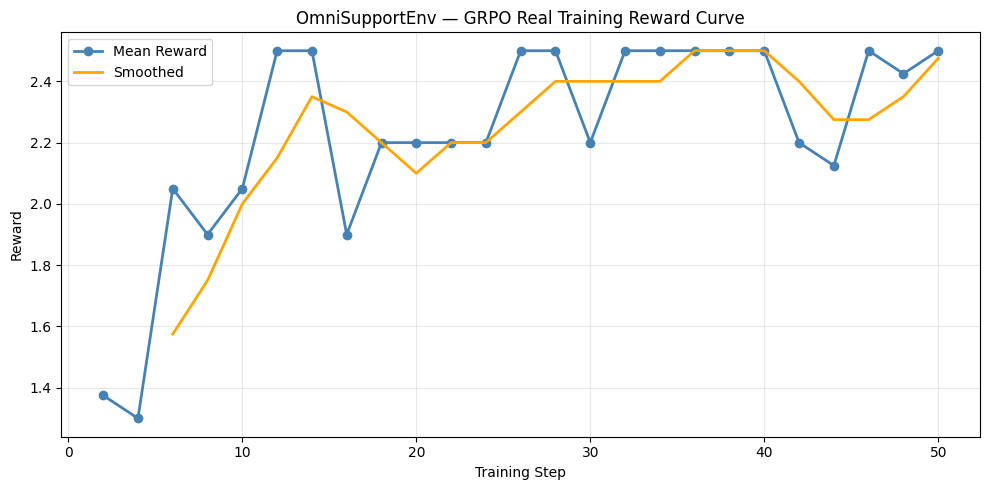

In [5]:
import numpy as np

history = trainer.state.log_history
rewards = [h["eval_rewards/reward_first_step_env"] for h in history if "eval_rewards/reward_first_step_env" in h]
steps = [h["step"] for h in history if "eval_rewards/reward_first_step_env" in h]

if not rewards:
    # TRL might log under a different key depending on version, fallback to generic reward
    rewards = [h["reward"] for h in history if "reward" in h]
    steps = [h["step"] for h in history if "reward" in h]

if rewards:
    plt.figure(figsize=(10, 5))
    plt.plot(steps, rewards, marker='o', color='steelblue', linewidth=2, label='Mean Reward')

    # Smooth curve
    if len(rewards) > 3:
        window = min(3, len(rewards))
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(steps[window-1:], smoothed, color='orange', linewidth=2, label='Smoothed')

    plt.xlabel("Training Step")
    plt.ylabel("Reward")
    plt.title("OmniSupportEnv — GRPO Real Training Reward Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    png_path = "real_reward_curve.png"
    plt.savefig(png_path, dpi=150)
    print(f"Saved real training curve to {png_path}!")
    plt.show()
else:
    print("Could not find reward logs in trainer history.")
